# Model Building

This notebook trains and evaluates predictive models for cardiovascular disease (`disease`) using a leakage-safe workflow.


## Train / validation / test strategy 

This project uses a **single holdout test set** for the final evaluation and uses **cross-validation on the training set only** for model selection and hyperparameter tuning.

For an even more conservative evaluation during tuning, use nested cross-validation; this notebook uses the holdout test as the final unbiased check.

Why this split is appropriate here:
- The dataset has no timestamp column and no patient/group identifier, so a **stratified random split** is a reasonable default.
- If a patient identifier or repeated measurements are added later, switch to **patient-level/group splitting** to prevent the same patient appearing in both train and test.
- If time becomes relevant, switch to a **time-aware split** (train on past, test on future).

**Leakage:**   
All preprocessing steps were fit on the training data only and applied to validation/test sets.

In scikit-learn, we put preprocessing and the model in a single `Pipeline` and running cross-validation on the pipeline.


## Imports and configuration


In [62]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.model_selection import (
    GridSearchCV,
    RandomizedSearchCV,
    StratifiedKFold,
    cross_validate,
    train_test_split,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, RobustScaler, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    PrecisionRecallDisplay,
    RocCurveDisplay,
    average_precision_score,
    classification_report,
    roc_auc_score,
)

RANDOM_STATE = 21
TEST_SIZE = 0.2
N_SPLITS = 5
N_JOBS = 1  # set to -1 for all cores if your environment supports multiprocessing

plt.style.use('bmh')
sns.set()


## Load cleaned dataset

Load the cleaned dataset created in `notebooks/data_cleaning.ipynb`.


In [63]:
DATA_PATH = Path('../data/cleaned_data.csv')
df = pd.read_csv(DATA_PATH)

print('shape:', df.shape)
df.head()


shape: (64899, 14)


,age,gender,height,weight,systolic blood pressure,diastolic blood pressure,cholesterol,glucose,smoking,alcohol,physical activity,disease,bmi,weight status
0,50,Men,168,62.0,110,80,normal,normal,No,No,Yes,No,21.967120,Healthy
1,55,Women,156,85.0,140,90,well above normal,normal,No,No,Yes,Yes,34.927679,Obese
2,52,Women,165,64.0,130,70,well above normal,normal,No,No,No,Yes,23.507805,Healthy
3,48,Men,169,82.0,150,100,normal,normal,No,No,Yes,Yes,28.710479,Overweight
4,48,Women,156,56.0,100,60,normal,normal,No,No,No,No,23.011177,Healthy


## Define features (`X`) and target (`y`)

The target is `disease` (`Yes`/`No`), converted to `1`/`0`.


In [64]:
TARGET = 'disease'

X = df.drop(columns=[TARGET])
y = df[TARGET].map({'Yes': 1, 'No': 0}).astype(int)

print('positive prevalence:', y.mean().round(4))
X.columns


positive prevalence: 0.5087


Index(['age', 'gender', 'height', 'weight', 'systolic blood pressure',
       'diastolic blood pressure', 'cholesterol', 'glucose', 'smoking',
       'alcohol', 'physical activity', 'bmi', 'weight status'],
      dtype='object')

## Holdout test split 

Create a single **holdout test set** for the final evaluation.

- The split is **stratified** so it preserves class proportions in test set.
- The test set is not used for preprocessing, feature selection, or hyperparameter tuning.


In [65]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=TEST_SIZE,
    stratify=y,
    random_state=RANDOM_STATE,
)

print('train:', X_train.shape, 'test:', X_test.shape)
print('train prevalence:', y_train.mean().round(4))
print('test prevalence :', y_test.mean().round(4))


train: (51919, 13) test: (12980, 13)
train prevalence: 0.5087
test prevalence : 0.5087


## Preprocessing (`ColumnTransformer`)

Define preprocessing as a transformer that will be fit **inside** the model pipeline.

- **Numeric features**: scaled with `RobustScaler` (less sensitive to outliers).
- **Ordered categoricals**: encoded with `OrdinalEncoder` using explicit category order.
- **Nominal categoricals**: encoded with `OneHotEncoder(handle_unknown='ignore')`. Creates separate 0/1 indicator column for each category.


In [66]:
num_cols = [
    'age',
    'height',
    'weight',
    'bmi',
    'systolic blood pressure',
    'diastolic blood pressure',
]
ord_cols = ['cholesterol', 'glucose', 'weight status']
ohe_cols = ['gender', 'smoking', 'alcohol', 'physical activity']

ord_encoder = OrdinalEncoder(
    categories=[
        ['normal', 'above normal', 'well above normal'],
        ['normal', 'above normal', 'well above normal'],
        ['Underweight', 'Healthy', 'Overweight', 'Obese'],
    ],
    handle_unknown='use_encoded_value',
    unknown_value=-1,
)

ohe = OneHotEncoder(
    handle_unknown='ignore',
    drop='if_binary',
    sparse_output=False,
)

preprocessor = ColumnTransformer(
    transformers=[
        ('num', RobustScaler(), num_cols),
        ('ord', ord_encoder, ord_cols),
        ('ohe', ohe, ohe_cols),
    ]
)


## Quick check: scaling choice on training only

This is a visualization-only check to understand scaling behavior. The scaler is fit on `X_train` only.  
Scaling shifts and rescales the x-axis.

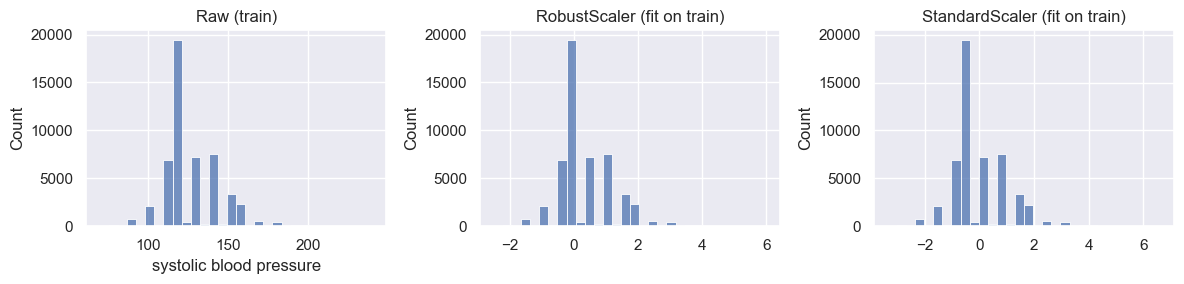

In [67]:
feature = 'systolic blood pressure'

fig, ax = plt.subplots(1, 3, figsize=(12, 3))

sns.histplot(X_train[feature], bins=30, ax=ax[0])
ax[0].set_title('Raw (train)')

robust_scaled = RobustScaler().fit_transform(X_train[[feature]])
sns.histplot(robust_scaled[:, 0], bins=30, ax=ax[1])
ax[1].set_title('RobustScaler (fit on train)')

standard_scaled = StandardScaler().fit_transform(X_train[[feature]])
sns.histplot(standard_scaled[:, 0], bins=30, ax=ax[2])
ax[2].set_title('StandardScaler (fit on train)')

plt.tight_layout()
plt.show()


## Baseline models (pipelines)

Create end-to-end pipelines that include preprocessing and the estimator. This is the main leakage prevention mechanism.

Note: the XGBoost baseline requires `xgboost` (pip) and on macOS typically also `libomp` (Homebrew: `brew install libomp`).


In [68]:
cv = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)

pipelines = {
    'logreg': Pipeline(
        steps=[
            ('preprocess', preprocessor),
            ('clf', LogisticRegression(max_iter=2000, random_state=RANDOM_STATE)),
        ]
    ),
    'random_forest': Pipeline(
        steps=[
            ('preprocess', preprocessor),
            (
                'clf',
                RandomForestClassifier(
                    n_estimators=500,
                    random_state=RANDOM_STATE,
                    n_jobs=N_JOBS,
                ),
            ),
        ]
    ),
    'xgboost': Pipeline(
        steps=[
            ('preprocess', preprocessor),
            (
                'clf',
                XGBClassifier(
                    objective='binary:logistic',
                    eval_metric='logloss',
                    tree_method='hist',
                    n_estimators=500,
                    learning_rate=0.05,
                    max_depth=4,
                    subsample=0.9,
                    colsample_bytree=0.9,
                    reg_lambda=1.0,
                    random_state=RANDOM_STATE,
                    n_jobs=N_JOBS,
                    verbosity=0,
                ),
            ),
        ]
    ),
}

scoring = {
    'roc_auc': 'roc_auc',
    'avg_precision': 'average_precision',
    'accuracy': 'accuracy',
    'precision': 'precision',
    'recall': 'recall',
    'f1': 'f1',
}


**Scoring metrics)**

**2.1 Accuracy (`accuracy`)**
- Definition: $\frac{TP+TN}{TP+TN+FP+FN}$
- Rewards: overall correctness
- Problem: can be misleading with class imbalance
- Example: if 90% don’t have CVD, predicting “no CVD” for everyone gives 90% accuracy (but is useless)
- Verdict: generally not a primary medical risk metric; keep as a sanity check

**2.2 Precision (`precision`)**
- Definition: $\frac{TP}{TP+FP}$
- Answers: “When the model predicts disease, how often is it correct?”
- Rewards: few false positives
- Matters when: false alarms are costly (e.g., expensive follow-up)
- Verdict: useful diagnostic metric, rarely the only objective

**2.3 Recall / Sensitivity (`recall`)**
- Definition: $\frac{TP}{TP+FN}$
- Answers: “How many actual sick patients did we catch?”
- Rewards: few false negatives
- Medical note: missing disease is often worse than a false alarm
- Verdict: often important for screening; alone it ignores false positives

**2.4 F1 score (`f1`)**
- Definition: $2\cdot\frac{\text{precision}\cdot\text{recall}}{\text{precision}+\text{recall}}$
- What it is: balance of precision and recall
- Limitation: threshold-based (depends on a chosen cutoff); not probability-aware
- Verdict: reasonable threshold-based summary, but not ideal when calibrated probabilities matter

**3. Probability-based metrics (usually better for model selection)**
These use predicted probabilities (ranking), not hard labels.

**3.1 ROC-AUC (`roc_auc`)**

- ROC curve plots True Positive Rate (Sensitivity) against False Positive Rate (1-Specificity)
- Measures: how well the model ranks positives above negatives across all thresholds
- Interpretation: 0.5=random, 1.0=perfect ranking
- Why it’s popular: threshold-independent, stable for model comparison
- Nuance: does not guarantee good calibration or performance at a specific clinical threshold
- Verdict: excellent default model selection metric

**3.2 PR-AUC (`average_precision`)**
- Measures: precision–recall tradeoff across thresholds
- Better than ROC-AUC when: strong class imbalance and positives are the focus
- Downside: less intuitive; higher variance across folds
- Verdict: consider when prevalence is very low; otherwise ROC-AUC is often sufficient

Practical note: choose any operating threshold using training/CV only; evaluate the holdout test once at the end.

## Baseline comparison via cross-validation 

Run CV on the **training split only** to compare baselines. Each fold fits preprocessing and the model using only that fold's training data.


In [ ]:
rows = []
for name, pipe in pipelines.items():
    scores = cross_validate(
        pipe,
        X_train,
        y_train,
        cv=cv,
        scoring=scoring,
        n_jobs=N_JOBS,
        return_train_score=False,
    )
    row = {'model': name}
    #row is dictionary
    #rows is a list of dictionaries 
    for metric in scoring:
        row[f'{metric}_mean'] = float(np.mean(scores[f'test_{metric}']))
        row[f'{metric}_std'] = float(np.std(scores[f'test_{metric}']))
    rows.append(row)

cv_results = pd.DataFrame(rows).sort_values('roc_auc_mean', ascending=False)
cv_results

,model,roc_auc_mean,roc_auc_std,avg_precision_mean,avg_precision_std,accuracy_mean,accuracy_std,precision_mean,precision_std,recall_mean,recall_std,f1_mean,f1_std
2,xgboost,0.797143,0.003647,0.785531,0.005799,0.729560,0.004454,0.750249,0.004272,0.702083,0.009337,0.725333,0.005645
0,logreg,0.787582,0.003432,0.774393,0.002538,0.723377,0.005183,0.748326,0.003729,0.687353,0.011334,0.716503,0.007004
1,random_forest,0.750736,0.004471,0.744638,0.005425,0.696681,0.003215,0.703325,0.001809,0.698258,0.010413,0.700741,0.005256


In [61]:
print(row)
print(rows)

{'model': 'xgboost', 'roc_auc_mean': 0.7971434706574757, 'roc_auc_std': 0.0036471743748783566, 'avg_precision_mean': 0.7855310369468973, 'avg_precision_std': 0.005799246087838406, 'accuracy_mean': 0.7295595821782286, 'accuracy_std': 0.004454297715354876, 'precision_mean': 0.7502487661353178, 'precision_std': 0.004272286598035183, 'recall_mean': 0.7020825444907233, 'recall_std': 0.009336945339840835, 'f1_mean': 0.7253329330387557, 'f1_std': 0.005644845333504657}
[{'model': 'logreg', 'roc_auc_mean': 0.7875820572211809, 'roc_auc_std': 0.0034318505617684947, 'avg_precision_mean': 0.7743933329978558, 'avg_precision_std': 0.0025380229156140204, 'accuracy_mean': 0.7233768618758262, 'accuracy_std': 0.005182883008345892, 'precision_mean': 0.7483257237624449, 'precision_std': 0.003728920100408464, 'recall_mean': 0.6873532752745172, 'recall_std': 0.011334441994347176, 'f1_mean': 0.7165026977756209, 'f1_std': 0.007004421501287236}, {'model': 'random_forest', 'roc_auc_mean': 0.7507362214746766, 'ro

## Hyperparameter tuning for the best baseline 

Tune only on the training split using cross-validation.

Baseline selection uses mean CV ROC-AUC (`roc_auc_mean`). For different objectives (e.g., prioritize recall/sensitivity), change the selection metric and `scoring=` accordingly.

- Logistic Regression: small grid search (fast).
- Random Forest: randomized search (can take longer).

So: baseline CV compares model families; tuning CV compares hyperparameter settings within the chosen model family.

In [69]:
best_baseline_name = cv_results.iloc[0]['model']
print('best baseline:', best_baseline_name)

if best_baseline_name == 'logreg':
    param_grid = {
        'clf__C': [0.01, 0.1, 1.0, 10.0],
        'clf__class_weight': [None, 'balanced'],
    }
    search = GridSearchCV(
        pipelines['logreg'],
        param_grid=param_grid,
        scoring='roc_auc',
        cv=cv,
        n_jobs=N_JOBS,
        refit=True,
    )
elif best_baseline_name == 'random_forest':
    param_distributions = {
        'clf__n_estimators': [300, 500, 800],
        'clf__max_depth': [None, 5, 10, 20],
        'clf__min_samples_split': [2, 5, 10],
        'clf__min_samples_leaf': [1, 2, 5],
        'clf__max_features': ['sqrt', 'log2', 0.5],
    }
    search = RandomizedSearchCV(
        pipelines['random_forest'],
        param_distributions=param_distributions,
        n_iter=20,
        scoring='roc_auc',
        cv=cv,
        n_jobs=N_JOBS,
        random_state=RANDOM_STATE,
        refit=True,
    )
elif best_baseline_name == 'xgboost':
    param_distributions = {
        'clf__n_estimators': [300, 500, 800],
        'clf__max_depth': [3, 4, 5, 6],
        'clf__learning_rate': [0.01, 0.05, 0.1, 0.2],
        'clf__subsample': [0.7, 0.85, 1.0],
        'clf__colsample_bytree': [0.7, 0.85, 1.0],
        'clf__min_child_weight': [1, 5, 10],
        'clf__reg_lambda': [0.5, 1.0, 5.0, 10.0],
    }
    search = RandomizedSearchCV(
        pipelines['xgboost'],
        param_distributions=param_distributions,
        n_iter=25,
        scoring='roc_auc',
        cv=cv,
        n_jobs=N_JOBS,
        random_state=RANDOM_STATE,
        refit=True,
    )
else:
    raise ValueError(f'unknown baseline: {best_baseline_name}')

search.fit(X_train, y_train)

print('best CV ROC-AUC:', round(search.best_score_, 4))
search.best_params_

best baseline: xgboost
best CV ROC-AUC: 0.798


{'clf__subsample': 1.0,
 'clf__reg_lambda': 1.0,
 'clf__n_estimators': 500,
 'clf__min_child_weight': 1,
 'clf__max_depth': 5,
 'clf__learning_rate': 0.01,
 'clf__colsample_bytree': 0.7}

## Final evaluation on the holdout test set

This is the first time the holdout test set is used for performance reporting. Avoid iterating on model decisions after seeing these results.

Note: the classification report uses a default probability threshold of `0.5`. In practice, choose an operating threshold using only training/CV results (e.g., target recall/sensitivity).


In [ ]:
#search.best_estimator_
test_proba = final_model.predict_proba(X_test)[:, 1]
print(test_proba)

Test ROC-AUC: 0.8
Test PR-AUC : 0.7891

              precision    recall  f1-score   support

           0      0.711     0.769     0.739      6377
           1      0.758     0.698     0.727      6603

    accuracy                          0.733     12980
   macro avg      0.734     0.733     0.733     12980
weighted avg      0.735     0.733     0.733     12980



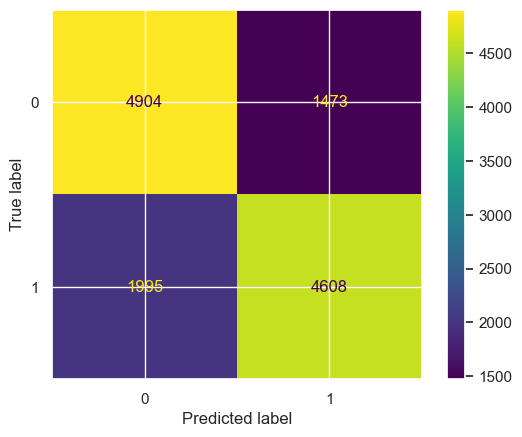

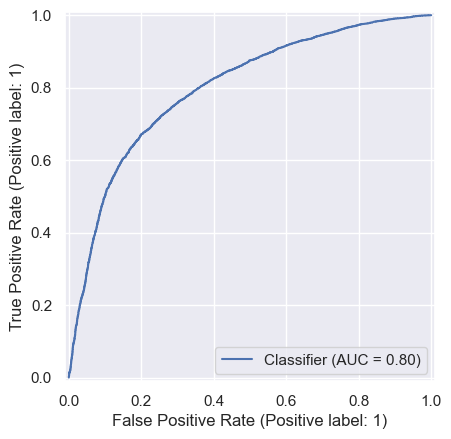

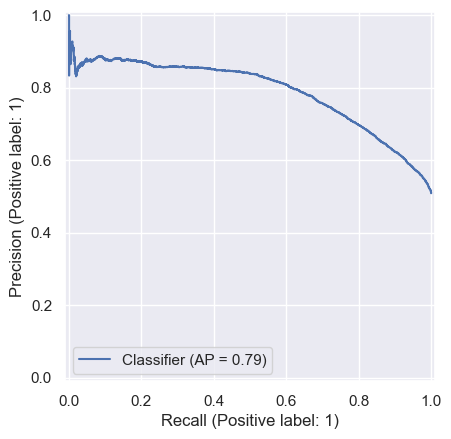

{'model_family': 'xgboost',
 'best_cv_roc_auc': 0.798038327697962,
 'test_roc_auc': 0.8000071768975335,
 'test_pr_auc': 0.789098367014536}

In [70]:
final_model = search.best_estimator_

test_proba = final_model.predict_proba(X_test)[:, 1]
test_pred = (test_proba >= 0.5).astype(int)

print('Test ROC-AUC:', round(roc_auc_score(y_test, test_proba), 4))
print('Test PR-AUC :', round(average_precision_score(y_test, test_proba), 4))
print()
print(classification_report(y_test, test_pred, digits=3))

ConfusionMatrixDisplay.from_predictions(y_test, test_pred)
plt.show()

RocCurveDisplay.from_predictions(y_test, test_proba)
plt.show()

PrecisionRecallDisplay.from_predictions(y_test, test_proba)
plt.show()

test_metrics = {
    'model_family': best_baseline_name,
    'best_cv_roc_auc': float(search.best_score_),
    'test_roc_auc': float(roc_auc_score(y_test, test_proba)),
    'test_pr_auc': float(average_precision_score(y_test, test_proba)),
}
test_metrics
